# SCNN v3 — Circular Channel Augmentation + FHT

Key changes from v1/v2:
1. **Circular channel augmentation** — simulate electrode shift by rotating 8 channels (8× training data)
2. **FHT envelope** — proven critical from ablation study
3. **Larger filters** (48→96→192) — more capacity while still << CNN 101K params

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from config import MODELS_DIR, RANDOM_SEED, N_CLASSES, get_device
from src.data_splitter import (
    scenario_1_ideal,
    scenario_2_per_position,
    scenario_3_inter_subject,
    scenario_4_interday,
    scenario_5_fatigue,
)
from src.feature_extraction import fht_envelope_batch
from src.evaluation import print_report, plot_confusion_matrix, measure_latency, print_latency

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: mps


## Circular Channel Augmentation

In [2]:
def circular_augment(X, y):
    # X: (N, 8, 50) — rotate channels circularly to simulate electrode shift
    # Returns: (N*8, 8, 50) — 8 rotations per window (including original)
    N, C, T = X.shape
    X_aug = np.empty((N * C, C, T), dtype=X.dtype)
    y_aug = np.empty(N * C, dtype=y.dtype)

    for shift in range(C):
        X_aug[shift * N:(shift + 1) * N] = np.roll(X, shift=shift, axis=1)
        y_aug[shift * N:(shift + 1) * N] = y

    # Shuffle to mix shifts within batches
    rng = np.random.RandomState(RANDOM_SEED)
    idx = rng.permutation(len(y_aug))
    return X_aug[idx], y_aug[idx]


# Quick test
test_X = np.arange(24).reshape(1, 8, 3).astype(np.float32)
test_y = np.array([0])
aug_X, aug_y = circular_augment(test_X, test_y)
print(f"Input: {test_X.shape} -> Augmented: {aug_X.shape} ({aug_X.shape[0]}x)")
print(f"Original ch order: {test_X[0, :, 0].astype(int)}")
for i in range(8):
    row = aug_X[i, :, 0].astype(int)
    print(f"  Rotation {i}: {row}")

Input: (1, 8, 3) -> Augmented: (8, 8, 3) (8x)
Original ch order: [ 0  3  6  9 12 15 18 21]
  Rotation 0: [21  0  3  6  9 12 15 18]
  Rotation 1: [ 9 12 15 18 21  0  3  6]
  Rotation 2: [ 0  3  6  9 12 15 18 21]
  Rotation 3: [ 3  6  9 12 15 18 21  0]
  Rotation 4: [18 21  0  3  6  9 12 15]
  Rotation 5: [12 15 18 21  0  3  6  9]
  Rotation 6: [15 18 21  0  3  6  9 12]
  Rotation 7: [ 6  9 12 15 18 21  0  3]


## Model — Larger Separable CNN

In [3]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_ch, in_ch, kernel_size, padding=padding, groups=in_ch)
        self.pointwise = nn.Conv2d(in_ch, out_ch, kernel_size=1)
    def forward(self, x): return self.pointwise(self.depthwise(x))


class SeparableCNNv3(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            DepthwiseSeparableConv(1, 48, 3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(48, 96, 3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(96, 192, 3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(192, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, n_classes),
        )

    def forward(self, x): return self.classifier(self.features(x))


model = SeparableCNNv3().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"SCNN v3 Parameters: {n_params:,}")
print(f"SCNN v1 had:        20,625")
print(f"CNN had:            101,831")
print(f"Reduction vs CNN:   {101831 / n_params:.1f}×")

SCNN v3 Parameters: 44,753
SCNN v1 had:        20,625
CNN had:            101,831
Reduction vs CNN:   2.3×


## Training utilities

In [4]:
def prepare_train(X, y, augment=True):
    # FHT -> augment (train only) -> tensor
    X_fht = fht_envelope_batch(X)
    if augment:
        X_fht, y = circular_augment(X_fht, y)
        print(f"After augmentation: {X_fht.shape[0]:,} windows (8× original)")
    X_t = torch.from_numpy(X_fht).float().unsqueeze(1)
    y_t = torch.from_numpy(y).long()
    return DataLoader(TensorDataset(X_t, y_t), batch_size=256, shuffle=True)


def prepare_test(X):
    # FHT only, NO augmentation
    X_fht = fht_envelope_batch(X)
    return X_fht


def train_model(model, train_loader, n_epochs=30, lr=1e-3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    criterion = nn.CrossEntropyLoss()

    history = []
    for epoch in range(n_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)
        scheduler.step()
        epoch_loss = total_loss / total
        epoch_acc = correct / total
        history.append({"loss": epoch_loss, "acc": epoch_acc})
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} — loss: {epoch_loss:.4f}, acc: {epoch_acc:.4f}")
    return history


@torch.no_grad()
def predict(model, X_fht):
    model.eval()
    X_t = torch.from_numpy(X_fht).float().unsqueeze(1)
    loader = DataLoader(TensorDataset(X_t), batch_size=512, shuffle=False)
    preds = []
    for (xb,) in loader:
        preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(preds)

---
## Scenario 1 — Ideal

In [5]:
X_train, y_train, X_test, y_test, info = scenario_1_ideal()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Loading windows: 100%|██████████| 251/251 [00:00<00:00, 1345.00it/s]


Train: (59159, 8, 50), Test: (29281, 8, 50)


In [6]:
loader_s1 = prepare_train(X_train, y_train, augment=False)
scnn_s1 = SeparableCNNv3().to(DEVICE)
hist_s1 = train_model(scnn_s1, loader_s1, n_epochs=40)

Epoch   1/40 — loss: 1.2565, acc: 0.5219
Epoch   5/40 — loss: 0.8948, acc: 0.6681
Epoch  10/40 — loss: 0.7924, acc: 0.7035
Epoch  15/40 — loss: 0.7267, acc: 0.7293
Epoch  20/40 — loss: 0.6808, acc: 0.7477
Epoch  25/40 — loss: 0.6455, acc: 0.7597
Epoch  30/40 — loss: 0.6226, acc: 0.7699
Epoch  35/40 — loss: 0.6132, acc: 0.7727
Epoch  40/40 — loss: 0.6067, acc: 0.7752



  SCNNv3 — Scenario 1 (Ideal)
  Accuracy:  0.7315
  F1-macro:  0.7333
                    precision    recall  f1-score   support

              fist       0.86      0.83      0.84      4208
         open_hand       0.72      0.70      0.71      4179
  pinch_forefinger       0.61      0.59      0.60      4204
pinch_middlefinger       0.61      0.67      0.64      4239
               two       0.69      0.76      0.72      4175
          eversion       0.87      0.76      0.81      4064
             varus       0.81      0.81      0.81      4212

          accuracy                           0.73     29281
         macro avg       0.74      0.73      0.73     29281
      weighted avg       0.74      0.73      0.73     29281



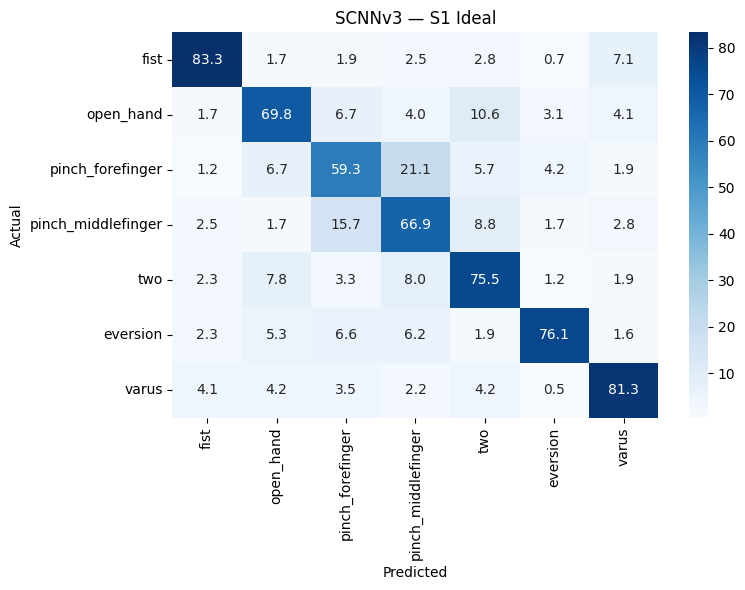

array([[3505,   72,   82,  104,  118,   28,  299],
       [  70, 2919,  279,  169,  441,  130,  171],
       [  49,  282, 2491,  886,  239,  177,   80],
       [ 105,   73,  665, 2837,  372,   70,  117],
       [  94,  324,  137,  335, 3154,   51,   80],
       [  92,  216,  268,  254,   77, 3091,   66],
       [ 173,  176,  149,   92,  179,   20, 3423]])

In [7]:
X_test_fht = prepare_test(X_test)
y_pred = predict(scnn_s1, X_test_fht)
metrics_s1 = print_report(y_test, y_pred, title="SCNNv3 — Scenario 1 (Ideal)")
plot_confusion_matrix(y_test, y_pred, title="SCNNv3 — S1 Ideal")

In [8]:
# Per-subject evaluation
from src.data_splitter import load_metadata, load_windows_from_metadata, compute_normalization_stats, apply_normalization

meta = load_metadata()
subset = meta[(meta["session"] == 0) & (meta["position"] == 0)]

per_subject_acc = {}
for subj in sorted(subset["subject"].unique()):
    subj_df = subset[subset["subject"] == subj]
    train_df = subj_df[subj_df["repetition"].isin([0, 1])]
    test_df = subj_df[subj_df["repetition"] == 2]

    X_tr, y_tr = load_windows_from_metadata(train_df, verbose=False)
    X_te, y_te = load_windows_from_metadata(test_df, verbose=False)

    mean, std = compute_normalization_stats(X_tr)
    X_tr = apply_normalization(X_tr, mean, std)
    X_te = apply_normalization(X_te, mean, std)

    loader = prepare_train(X_tr, y_tr, augment=False)
    m = SeparableCNNv3().to(DEVICE)
    train_model(m, loader, n_epochs=40, lr=1e-3)
    X_te_fht = prepare_test(X_te)
    y_pred = predict(m, X_te_fht)
    per_subject_acc[subj] = accuracy_score(y_te, y_pred)

accs = list(per_subject_acc.values())
print(f"\nPer-subject accuracy: mean={np.mean(accs):.4f}, min={np.min(accs):.4f}, max={np.max(accs):.4f}")
print()
for subj, acc in sorted(per_subject_acc.items()):
    bar = "█" * int(acc * 40)
    print(f"  {subj:4s}: {acc:.3f} {bar}")

Epoch   1/40 — loss: 1.8662, acc: 0.2812
Epoch   5/40 — loss: 0.9044, acc: 0.7079
Epoch  10/40 — loss: 0.5013, acc: 0.8136
Epoch  15/40 — loss: 0.3469, acc: 0.8815
Epoch  20/40 — loss: 0.2993, acc: 0.8937
Epoch  25/40 — loss: 0.2651, acc: 0.9116
Epoch  30/40 — loss: 0.2449, acc: 0.9218
Epoch  35/40 — loss: 0.2474, acc: 0.9103
Epoch  40/40 — loss: 0.2443, acc: 0.9206
Epoch   1/40 — loss: 1.8673, acc: 0.2629
Epoch   5/40 — loss: 1.3202, acc: 0.6112
Epoch  10/40 — loss: 0.7014, acc: 0.7896
Epoch  15/40 — loss: 0.4941, acc: 0.8478
Epoch  20/40 — loss: 0.4220, acc: 0.8550
Epoch  25/40 — loss: 0.3755, acc: 0.8733
Epoch  30/40 — loss: 0.3500, acc: 0.8861
Epoch  35/40 — loss: 0.3498, acc: 0.8797
Epoch  40/40 — loss: 0.3528, acc: 0.8829
Epoch   1/40 — loss: 1.7718, acc: 0.3233
Epoch   5/40 — loss: 0.7989, acc: 0.6997
Epoch  10/40 — loss: 0.3970, acc: 0.8656
Epoch  15/40 — loss: 0.2758, acc: 0.9082
Epoch  20/40 — loss: 0.2447, acc: 0.9193
Epoch  25/40 — loss: 0.2051, acc: 0.9325
Epoch  30/40 — l

In [9]:
torch.save(scnn_s1.state_dict(), MODELS_DIR / "scnn_v3_s1_ideal.pt")
print("Saved.")

Saved.


---
## Scenario 2 — Electrode Shift (the main event)

In [10]:
X_train_s2, y_train_s2, test_by_pos, info_s2 = scenario_2_per_position()
print(f"Train (raw): {X_train_s2.shape}")

loader_s2 = prepare_train(X_train_s2, y_train_s2, augment=True)

Loading windows: 100%|██████████| 629/629 [00:00<00:00, 2155.63it/s]


Train (raw): (71927, 8, 50)
After augmentation: 575,416 windows (8× original)


In [11]:
scnn_s2 = SeparableCNNv3().to(DEVICE)
hist_s2 = train_model(scnn_s2, loader_s2, n_epochs=40)

Epoch   1/40 — loss: 1.5931, acc: 0.3673
Epoch   5/40 — loss: 1.3625, acc: 0.4717
Epoch  10/40 — loss: 1.2764, acc: 0.5104
Epoch  15/40 — loss: 1.2326, acc: 0.5299
Epoch  20/40 — loss: 1.2002, acc: 0.5434
Epoch  25/40 — loss: 1.1782, acc: 0.5519
Epoch  30/40 — loss: 1.1616, acc: 0.5591
Epoch  35/40 — loss: 1.1505, acc: 0.5640
Epoch  40/40 — loss: 1.1483, acc: 0.5653


Position  1: acc = 0.3710
Position  2: acc = 0.3259
Position  3: acc = 0.3058
Position  4: acc = 0.2621
Position  5: acc = 0.2612
Position  6: acc = 0.2782
Position  7: acc = 0.3363
Position  8: acc = 0.3741
Position  9: acc = 0.3119
Position 10: acc = 0.2775

Average shift accuracy: 0.3104


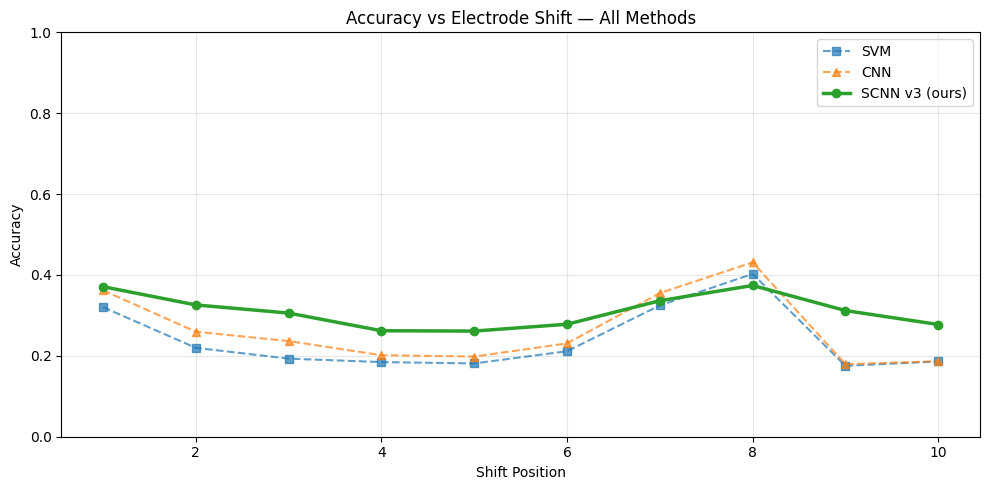

In [12]:
acc_per_pos = {}
for pos, (X_pos, y_pos) in sorted(test_by_pos.items()):
    X_pos_fht = prepare_test(X_pos)
    y_pred = predict(scnn_s2, X_pos_fht)
    acc_per_pos[pos] = accuracy_score(y_pos, y_pred)
    print(f"Position {pos:2d}: acc = {acc_per_pos[pos]:.4f}")

print(f"\nAverage shift accuracy: {np.mean(list(acc_per_pos.values())):.4f}")

# Comparison plot
svm_shift = [0.3203, 0.2198, 0.1931, 0.1846, 0.1812, 0.2115, 0.3247, 0.4026, 0.1753, 0.1862]
cnn_shift = [0.3620, 0.2597, 0.2365, 0.2016, 0.1982, 0.2308, 0.3552, 0.4312, 0.1794, 0.1866]
scnn_v3_shift = [acc_per_pos[p] for p in range(1, 11)]

plt.figure(figsize=(10, 5))
positions = list(range(1, 11))
plt.plot(positions, svm_shift, "s--", label="SVM", alpha=0.7)
plt.plot(positions, cnn_shift, "^--", label="CNN", alpha=0.7)
plt.plot(positions, scnn_v3_shift, "o-", label="SCNN v3 (ours)", linewidth=2.5)
plt.xlabel("Shift Position")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Electrode Shift — All Methods")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "all_methods_shift_curve.png"), dpi=150)
plt.show()

In [13]:
torch.save(scnn_s2.state_dict(), MODELS_DIR / "scnn_v3_s2_shift.pt")
print("Saved.")

Saved.


---
## Scenario 3 — Inter-Subject

In [14]:
X_train_s3, y_train_s3, X_test_s3, y_test_s3, info_s3 = scenario_3_inter_subject()
print(f"Train: {X_train_s3.shape} ({len(info_s3['train_subjects'])} subjects)")
print(f"Test:  {X_test_s3.shape} ({info_s3['test_subjects']})")

Loading windows: 100%|██████████| 1385/1385 [00:00<00:00, 1436.96it/s]


Train: (618926, 8, 50) (24 subjects)
Test:  (168232, 8, 50) (['h7', 'h22', 'h3', 'h24', 'h16', 'h17'])


In [16]:
loader_s3 = prepare_train(X_train_s3, y_train_s3, augment=False)
scnn_s3 = SeparableCNNv3().to(DEVICE)
hist_s3 = train_model(scnn_s3, loader_s3, n_epochs=40)

Epoch   1/40 — loss: 1.4034, acc: 0.4570
Epoch   5/40 — loss: 1.1301, acc: 0.5704
Epoch  10/40 — loss: 1.0429, acc: 0.6061
Epoch  15/40 — loss: 1.0015, acc: 0.6241
Epoch  20/40 — loss: 0.9722, acc: 0.6362
Epoch  25/40 — loss: 0.9477, acc: 0.6453
Epoch  30/40 — loss: 0.9299, acc: 0.6528
Epoch  35/40 — loss: 0.9185, acc: 0.6570
Epoch  40/40 — loss: 0.9155, acc: 0.6586



  SCNNv3 — Scenario 3 (Inter-Subject)
  Accuracy:  0.4600
  F1-macro:  0.4557
                    precision    recall  f1-score   support

              fist       0.47      0.49      0.48     23888
         open_hand       0.42      0.54      0.48     23933
  pinch_forefinger       0.35      0.32      0.33     24284
pinch_middlefinger       0.38      0.28      0.32     24064
               two       0.52      0.52      0.52     23897
          eversion       0.62      0.66      0.64     24069
             varus       0.43      0.41      0.42     24097

          accuracy                           0.46    168232
         macro avg       0.46      0.46      0.46    168232
      weighted avg       0.46      0.46      0.46    168232



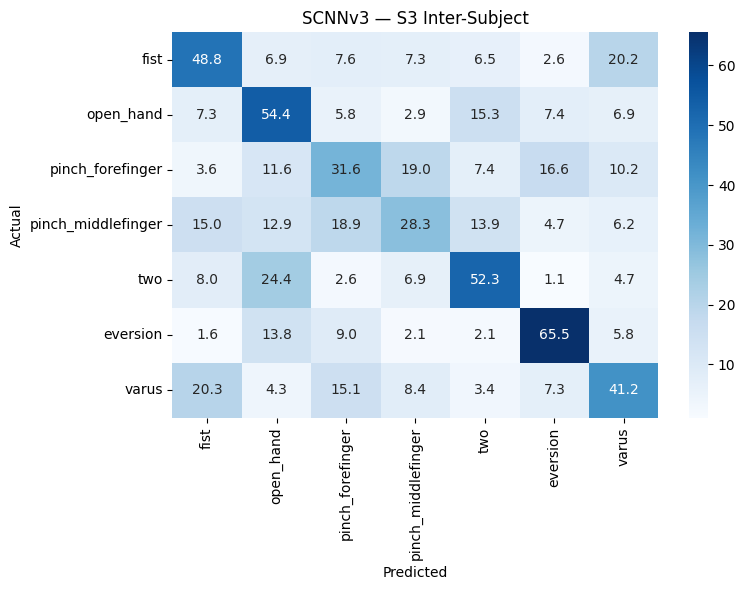

array([[11669,  1658,  1824,  1746,  1543,   621,  4827],
       [ 1757, 13022,  1390,   685,  3664,  1774,  1641],
       [  884,  2805,  7677,  4605,  1790,  4040,  2483],
       [ 3604,  3111,  4554,  6815,  3335,  1141,  1504],
       [ 1900,  5833,   611,  1647, 12508,   265,  1133],
       [  375,  3327,  2177,   499,   515, 15773,  1403],
       [ 4891,  1034,  3638,  2021,   828,  1758,  9927]])

In [17]:
X_test_s3_fht = prepare_test(X_test_s3)
y_pred_s3 = predict(scnn_s3, X_test_s3_fht)
metrics_s3 = print_report(y_test_s3, y_pred_s3, title="SCNNv3 — Scenario 3 (Inter-Subject)")
plot_confusion_matrix(y_test_s3, y_pred_s3, title="SCNNv3 — S3 Inter-Subject")

In [18]:
torch.save(scnn_s3.state_dict(), MODELS_DIR / "scnn_v3_s3_intersubject.pt")
print("Saved.")

Saved.


---
## Scenario 4 — Inter-Day

In [19]:
X_train_s4, y_train_s4, test_by_sess, info_s4 = scenario_4_interday()
print(f"Train: {X_train_s4.shape}")

loader_s4 = prepare_train(X_train_s4, y_train_s4, augment=False)
scnn_s4 = SeparableCNNv3().to(DEVICE)
hist_s4 = train_model(scnn_s4, loader_s4, n_epochs=40)

Loading windows: 100%|██████████| 126/126 [00:00<00:00, 1518.69it/s]


Train: (13445, 8, 50)
Epoch   1/40 — loss: 1.3787, acc: 0.4720
Epoch   5/40 — loss: 0.7266, acc: 0.7221
Epoch  10/40 — loss: 0.5966, acc: 0.7701
Epoch  15/40 — loss: 0.5257, acc: 0.7958
Epoch  20/40 — loss: 0.4712, acc: 0.8158
Epoch  25/40 — loss: 0.4415, acc: 0.8298
Epoch  30/40 — loss: 0.4249, acc: 0.8373
Epoch  35/40 — loss: 0.4102, acc: 0.8430
Epoch  40/40 — loss: 0.4047, acc: 0.8443


Session 1: acc = 0.5910
Session 2: acc = 0.6787
Session 3: acc = 0.6480
Session 4: acc = 0.6620
Session 5: acc = 0.5744
Session 6: acc = 0.6724
Session 7: acc = 0.6043
Session 8: acc = 0.6849
Session 9: acc = 0.5306


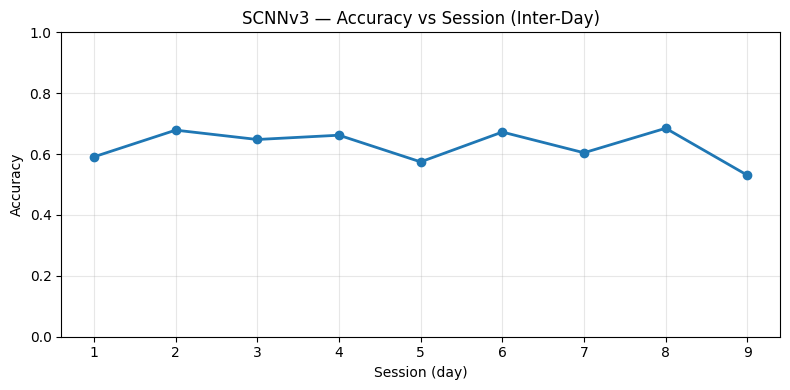

In [20]:
acc_per_sess = {}
for sess, (X_s, y_s) in sorted(test_by_sess.items()):
    X_s_fht = prepare_test(X_s)
    y_pred = predict(scnn_s4, X_s_fht)
    acc_per_sess[sess] = accuracy_score(y_s, y_pred)
    print(f"Session {sess}: acc = {acc_per_sess[sess]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_sess.keys()), list(acc_per_sess.values()), "o-", linewidth=2)
plt.xlabel("Session (day)")
plt.ylabel("Accuracy")
plt.title("SCNNv3 — Accuracy vs Session (Inter-Day)")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "scnn_v3_interday_curve.png"), dpi=150)
plt.show()

---
## Scenario 5 — Fatigue

In [21]:
X_train_s5, y_train_s5, test_by_fatigue, info_s5 = scenario_5_fatigue()
print(f"Train: {X_train_s5.shape}")

loader_s5 = prepare_train(X_train_s5, y_train_s5, augment=False)
scnn_s5 = SeparableCNNv3().to(DEVICE)
hist_s5 = train_model(scnn_s5, loader_s5, n_epochs=40)

Loading windows: 100%|██████████| 252/252 [00:00<00:00, 1437.95it/s]


Train: (33046, 8, 50)
Epoch   1/40 — loss: 0.9424, acc: 0.6573
Epoch   5/40 — loss: 0.3865, acc: 0.8601
Epoch  10/40 — loss: 0.3231, acc: 0.8823
Epoch  15/40 — loss: 0.2912, acc: 0.8912
Epoch  20/40 — loss: 0.2644, acc: 0.9007
Epoch  25/40 — loss: 0.2487, acc: 0.9070
Epoch  30/40 — loss: 0.2355, acc: 0.9127
Epoch  35/40 — loss: 0.2258, acc: 0.9156
Epoch  40/40 — loss: 0.2230, acc: 0.9162


Position  2: acc = 0.8856
Position  3: acc = 0.8693
Position  4: acc = 0.8738
Position  5: acc = 0.8830
Position  6: acc = 0.8728
Position  7: acc = 0.8919
Position  8: acc = 0.8394
Position  9: acc = 0.8611
Position 10: acc = 0.8373


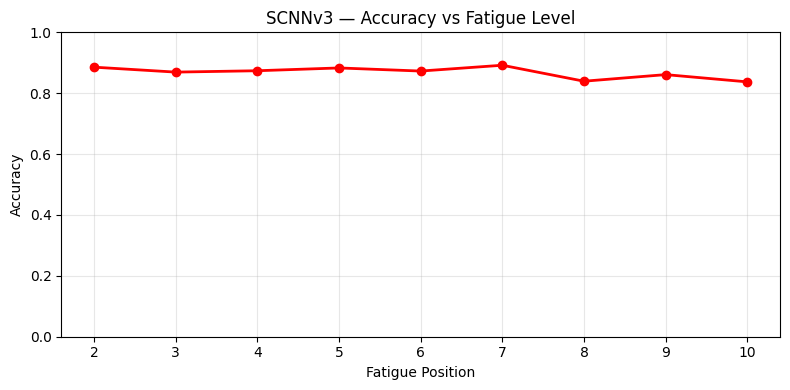

In [22]:
acc_per_fatigue = {}
for pos, (X_p, y_p) in sorted(test_by_fatigue.items()):
    X_p_fht = prepare_test(X_p)
    y_pred = predict(scnn_s5, X_p_fht)
    acc_per_fatigue[pos] = accuracy_score(y_p, y_pred)
    print(f"Position {pos:2d}: acc = {acc_per_fatigue[pos]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_fatigue.keys()), list(acc_per_fatigue.values()), "o-", linewidth=2, color="red")
plt.xlabel("Fatigue Position")
plt.ylabel("Accuracy")
plt.title("SCNNv3 — Accuracy vs Fatigue Level")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "scnn_v3_fatigue_curve.png"), dpi=150)
plt.show()

---
## Latency

In [23]:
scnn_s1.eval()
sample_raw = X_train[:1]

sample_fht = torch.from_numpy(prepare_test(sample_raw)).float().unsqueeze(1).to(DEVICE)
for _ in range(10):
    _ = scnn_s1(sample_fht)
if DEVICE.type == "mps":
    torch.mps.synchronize()

def scnn_v3_predict_single(x_raw):
    x_fht = prepare_test(x_raw)
    x_t = torch.from_numpy(x_fht).float().unsqueeze(1).to(DEVICE)
    with torch.no_grad():
        out = scnn_s1(x_t)
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    return out.argmax(1).cpu().numpy()

latency = measure_latency(scnn_v3_predict_single, sample_raw, n_runs=500)
print_latency(latency, model_name="SCNNv3 (FHT + inference)")
print(f"Parameters: {sum(p.numel() for p in scnn_s1.parameters()):,}")


Latency — SCNNv3 (FHT + inference)
  Mean:   1.78 ms
  Median: 1.68 ms
  P95:    1.82 ms
  <300ms: ✓
Parameters: 44,753


---
## Full Comparison

In [24]:
n_params = sum(p.numel() for p in scnn_s1.parameters())

print("\n" + "=" * 65)
print("FULL COMPARISON — ALL METHODS")
print("=" * 65)
print(f"{'Metric':<22} {'SVM':>8} {'CNN':>8} {'SCNNv1':>8} {'SCNNv3':>8}")
print("-" * 65)
print(f"{'S1 Ideal':<22} {'65.19%':>8} {'75.78%':>8} {'71.80%':>8} {metrics_s1['accuracy']*100:>7.2f}%")
print(f"{'S2 Shift (avg)':<22} {'23.99%':>8} {'26.41%':>8} {'24.78%':>8} {np.mean(list(acc_per_pos.values()))*100:>7.2f}%")
print(f"{'S3 Inter-subject':<22} {'40.27%':>8} {'52.90%':>8} {'48.51%':>8} {metrics_s3['accuracy']*100:>7.2f}%")
print(f"{'S4 Inter-day':<22} {'63.03%':>8} {'67.30%':>8} {'62.79%':>8} {np.mean(list(acc_per_sess.values()))*100:>7.2f}%")
print(f"{'S5 Fatigue':<22} {'81.20%':>8} {'86.98%':>8} {'84.96%':>8} {np.mean(list(acc_per_fatigue.values()))*100:>7.2f}%")
print(f"{'Latency p95 (ms)':<22} {'5.40':>8} {'1.74':>8} {'2.10':>8} {latency['p95_ms']:>7.2f}")
print(f"{'Parameters':<22} {'—':>8} {'101,831':>8} {'20,625':>8} {n_params:>8,}")
print("=" * 65)

print("\nS2 improvement over baselines:")
v3_avg = np.mean(list(acc_per_pos.values()))
print(f"  vs SVM (23.99%): +{(v3_avg - 0.2399)*100:.2f}%")
print(f"  vs CNN (26.41%): +{(v3_avg - 0.2641)*100:.2f}%")
print(f"  vs SCNN v1 (24.78%): +{(v3_avg - 0.2478)*100:.2f}%")


FULL COMPARISON — ALL METHODS
Metric                      SVM      CNN   SCNNv1   SCNNv3
-----------------------------------------------------------------
S1 Ideal                 65.19%   75.78%   71.80%   73.15%
S2 Shift (avg)           23.99%   26.41%   24.78%   31.04%
S3 Inter-subject         40.27%   52.90%   48.51%   46.00%
S4 Inter-day             63.03%   67.30%   62.79%   62.74%
S5 Fatigue               81.20%   86.98%   84.96%   86.82%
Latency p95 (ms)           5.40     1.74     2.10    1.82
Parameters                    —  101,831   20,625   44,753

S2 improvement over baselines:
  vs SVM (23.99%): +7.05%
  vs CNN (26.41%): +4.63%
  vs SCNN v1 (24.78%): +6.26%
